In [2]:
import pandas as pd

# URL halaman dengan tabel
url = "https://en.wikipedia.org/wiki/List_of_largest_companies_in_the_United_States_by_revenue"

# Ambil semua tabel
tables = pd.read_html(url)

# Pilih tabel utama (biasanya index 0 atau 1)
df = tables[0]  # tabel top daftar revenue


In [3]:
print("Nama kolom asli:", df.columns.tolist())
display(df.head())

# Contoh jika kolom seperti: ['Rank', 'Name', 'Industry', 'Revenue(USD millions)', ...]
df = df.rename(columns={
    'Name': 'Perusahaan',
    'Industry': 'Industri',
    'Revenue(USD millions)': 'Revenue_USD',
})


Nama kolom asli: ['Rank', 'Name', 'Industry', 'Revenue (USD millions)', 'Revenue growth', 'Employees', 'Headquarters']


,Rank,Name,Industry,Revenue (USD millions),Revenue growth,Employees,Headquarters
0,1,Walmart,Retail,648125,6.0%,2100000,"Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,574785,11.9%,1525000,"Seattle, Washington"
2,3,Apple,Electronics industry,383482,-2.8%,161000,"Cupertino, California"
3,4,UnitedHealth Group,Healthcare,371622,14.6%,440000,"Minnetonka, Minnesota"
4,5,Berkshire Hathaway,Conglomerate,364482,20.7%,396500,"Omaha, Nebraska"


In [4]:
import requests
from bs4 import BeautifulSoup
import re

def cari_website(nama):
    try:
        search = requests.get(f"https://www.google.com/search?q={nama}+official+site",
                              headers={"User-Agent": "Mozilla/5.0"})
        soup = BeautifulSoup(search.text, 'html.parser')
        a = soup.select_one('a[href^="http"]')
        if a:
            href = re.findall(r'https?://[^&]+', a['href'])
            return href[0] if href else None
    except:
        return None

def ekstrak_email(url):
    if not url: return []
    try:
        r = requests.get(url, timeout=5)
        return re.findall(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+", r.text)
    except:
        return []

df['website'] = df['Perusahaan'].apply(cari_website)
df['email'] = df['website'].apply(lambda u: ekstrak_email(u)[:2])


In [5]:
print(df.columns.tolist())


['Rank', 'Perusahaan', 'Industri', 'Revenue (USD millions)', 'Revenue growth', 'Employees', 'Headquarters', 'website', 'email']


In [6]:
display(df[['Rank', 'Perusahaan', 'Industri', 'Revenue (USD millions)', 'Revenue growth', 'Employees', 'Headquarters', 'website', 'email']].head(20))


,Rank,Perusahaan,Industri,Revenue (USD millions),Revenue growth,Employees,Headquarters,website,email
0,1,Walmart,Retail,648125,6.0%,2100000,"Bentonville, Arkansas",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
1,2,Amazon,Retail and cloud computing,574785,11.9%,1525000,"Seattle, Washington",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
2,3,Apple,Electronics industry,383482,-2.8%,161000,"Cupertino, California",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
3,4,UnitedHealth Group,Healthcare,371622,14.6%,440000,"Minnetonka, Minnesota",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
4,5,Berkshire Hathaway,Conglomerate,364482,20.7%,396500,"Omaha, Nebraska",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
5,6,CVS Health,Healthcare,357776,10.9%,259500,"Woonsocket, Rhode Island",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
6,7,ExxonMobil,Petroleum industry,344582,-16.7%,61500,"Spring, Texas",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
7,8,Alphabet,Technology and cloud computing,307394,8.7%,182502,"Mountain View, California",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
8,9,McKesson Corporation,Health,276711,4.8%,48000,"Irving, Texas",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."
9,10,Cencora,Pharmacy wholesale,262173,9.9%,44000,"Conshohocken, Pennsylvania",https://support.google.com/websearch,"[asxvmprobertest@gmail.com, smart.journey.prob..."


In [7]:
df.to_csv("data_perusahaan.csv", index=False)


In [118]:
from google.colab import files
files.download("data_perusahaan.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [119]:
import pandas as pd

# Load DataFrame
df = pd.read_csv("data_perusahaan.csv")  # atau langsung dari variabel df jika sudah ada

df.head()


,Rank,Perusahaan,Industri,Revenue (USD millions),Revenue growth,Employees,Headquarters,website,email
0,1,Walmart,Retail,648125,6.0%,2100000,"Bentonville, Arkansas",https://support.google.com/websearch,"['asxvmprobertest@gmail.com', 'smart.journey.p..."
1,2,Amazon,Retail and cloud computing,574785,11.9%,1525000,"Seattle, Washington",https://support.google.com/websearch,"['asxvmprobertest@gmail.com', 'smart.journey.p..."
2,3,Apple,Electronics industry,383482,-2.8%,161000,"Cupertino, California",https://support.google.com/websearch,"['asxvmprobertest@gmail.com', 'smart.journey.p..."
3,4,UnitedHealth Group,Healthcare,371622,14.6%,440000,"Minnetonka, Minnesota",https://support.google.com/websearch,"['asxvmprobertest@gmail.com', 'smart.journey.p..."
4,5,Berkshire Hathaway,Conglomerate,364482,20.7%,396500,"Omaha, Nebraska",https://support.google.com/websearch,"['asxvmprobertest@gmail.com', 'smart.journey.p..."


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Rank                    100 non-null    int64 
 1   Perusahaan              100 non-null    object
 2   Industri                100 non-null    object
 3   Revenue (USD millions)  100 non-null    int64 
 4   Revenue growth          100 non-null    object
 5   Employees               100 non-null    int64 
 6   Headquarters            100 non-null    object
 7   website                 100 non-null    object
 8   email                   100 non-null    object
dtypes: int64(3), object(6)
memory usage: 7.2+ KB


In [121]:
# Display a description of the dataset file
df.describe()

,Rank,Revenue (USD millions),Employees
count,100.000000,100.000000,1.000000e+02
mean,50.500000,122346.090000,1.626779e+05
std,29.011492,107882.041929,2.669024e+05
min,1.000000,43452.000000,4.137000e+03
25%,25.750000,54608.500000,4.500000e+04
50%,50.500000,80296.000000,8.650000e+04
75%,75.250000,149927.250000,1.891625e+05
max,100.000000,648125.000000,2.100000e+06


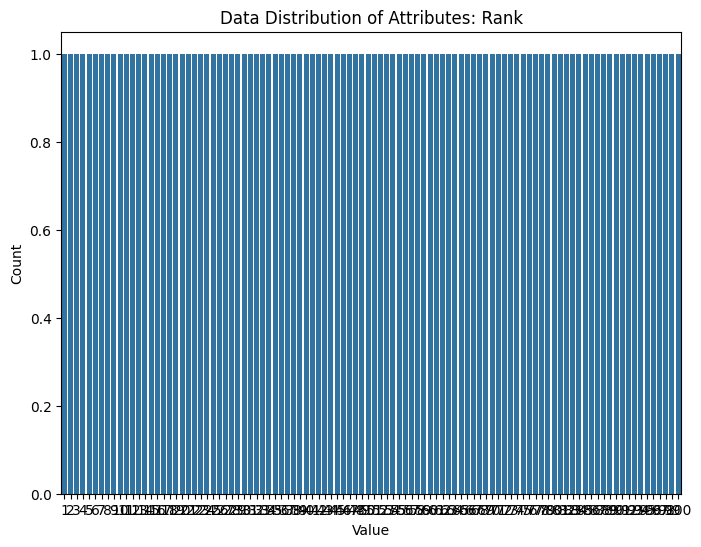

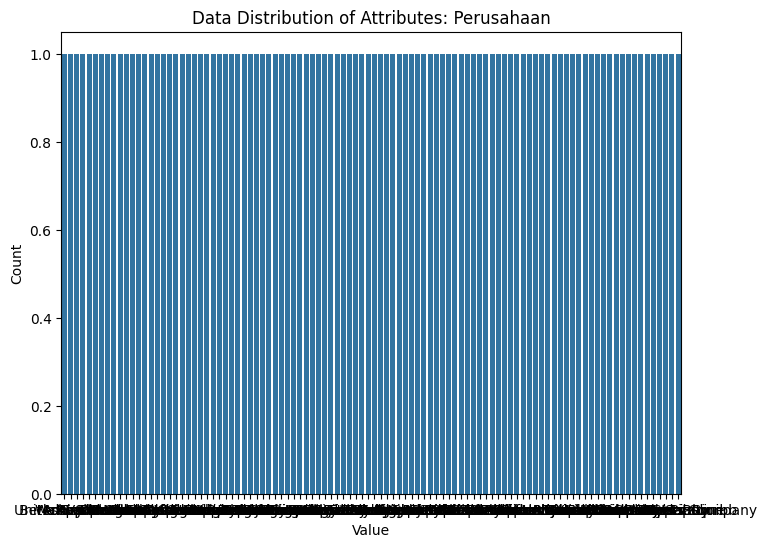

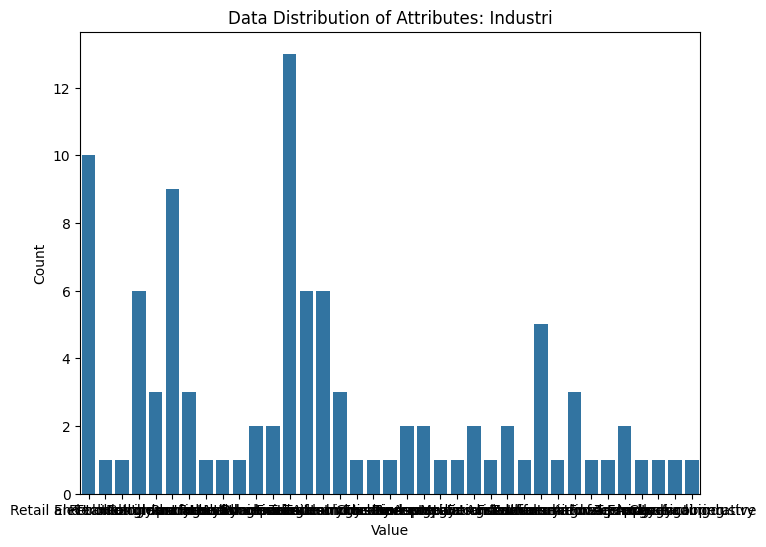

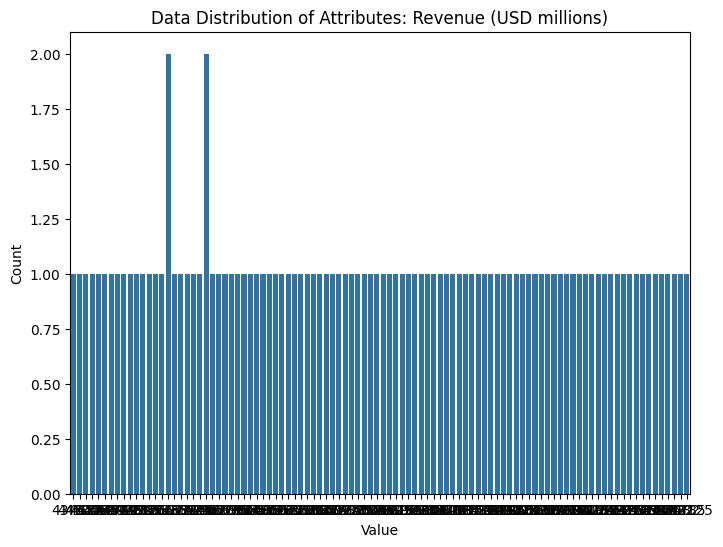

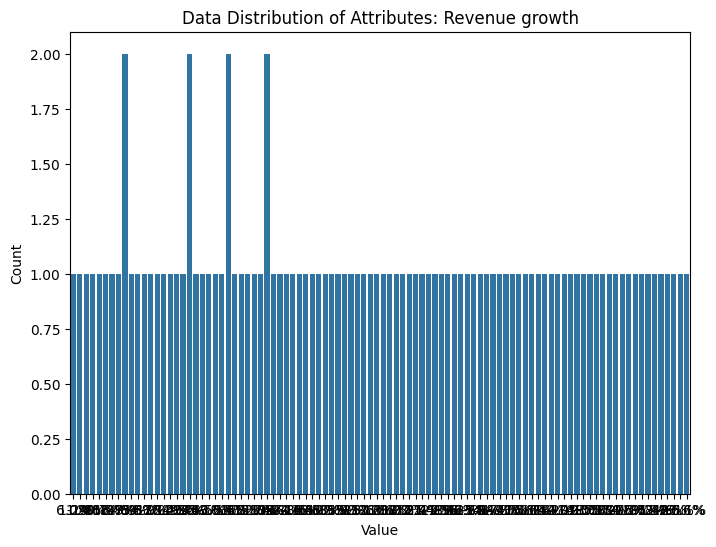

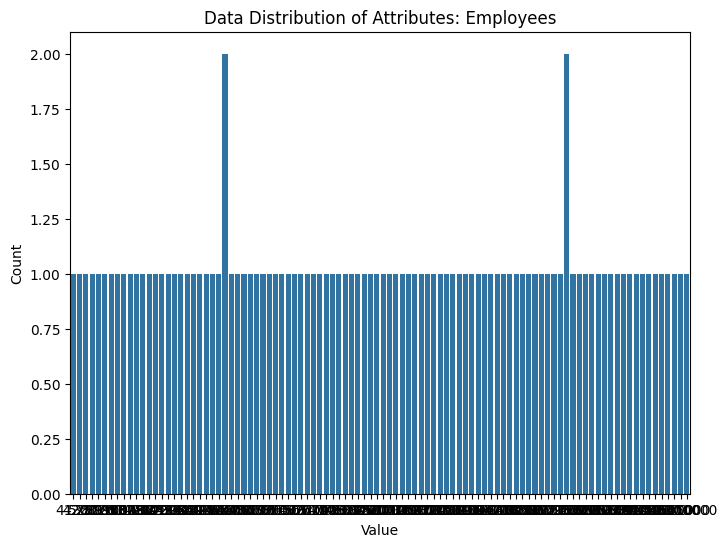

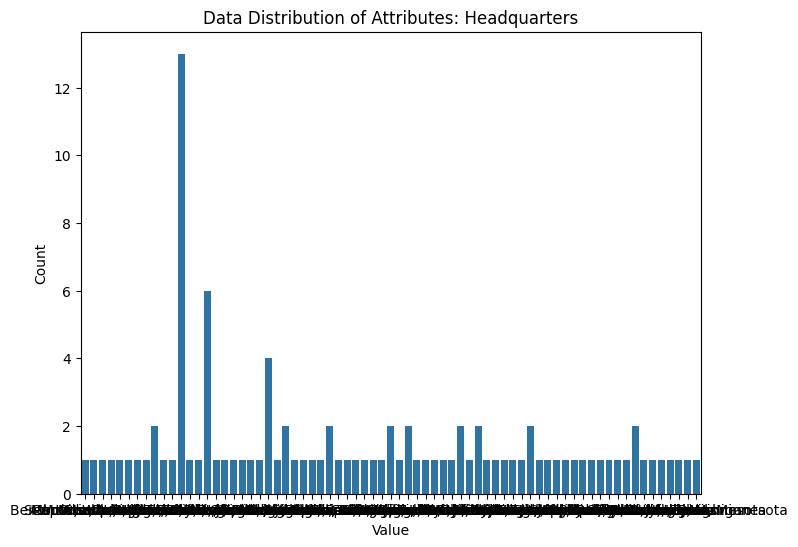

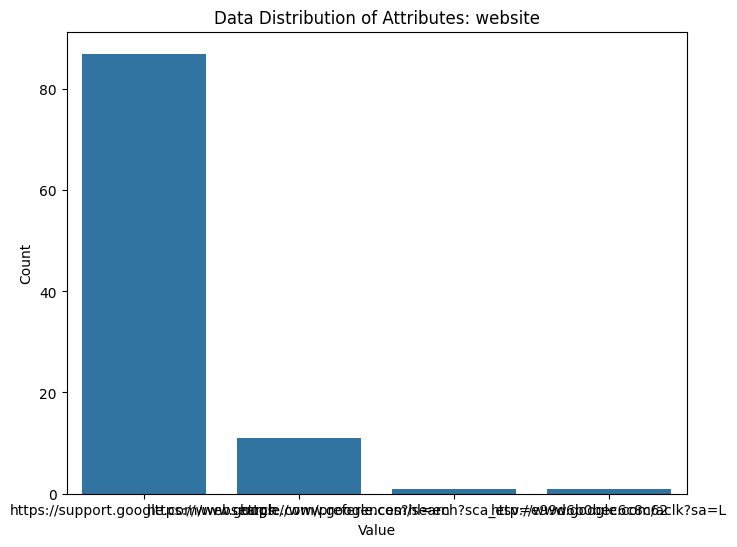

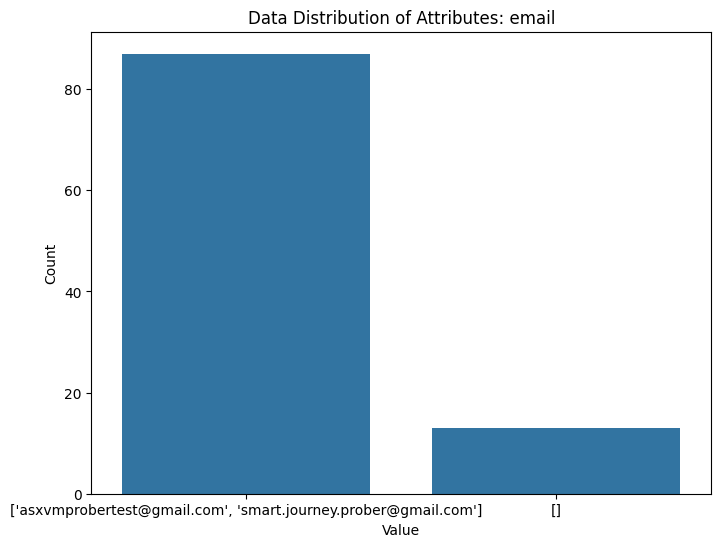

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display visualisations for each attribute
for atribut in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=atribut)
    plt.title('Data Distribution of Attributes: {}'.format(atribut))
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.show()

In [122]:
df.isnull().sum()

,0
Rank,0
Perusahaan,0
Industri,0
Revenue (USD millions),0
Revenue growth,0
Employees,0
Headquarters,0
website,0
email,0


In [123]:
# Displaying duplicate data
duplicate_rows = df.duplicated()
print("All Duplicate Rows:")
df[df.duplicated(keep=False)]

All Duplicate Rows:


,Rank,Perusahaan,Industri,Revenue (USD millions),Revenue growth,Employees,Headquarters,website,email


In [124]:
df.drop(columns=['website', 'email', 'Rank'], inplace=True)

In [125]:
dataClean = df
print(dataClean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Perusahaan              100 non-null    object
 1   Industri                100 non-null    object
 2   Revenue (USD millions)  100 non-null    int64 
 3   Revenue growth          100 non-null    object
 4   Employees               100 non-null    int64 
 5   Headquarters            100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
None


In [126]:
# Paksa tipe data ke string terlebih dahulu
dataClean['Revenue growth'] = dataClean['Revenue growth'].astype(str).str.replace('%', '').astype(float)


In [127]:
dataClean['Industri'] = dataClean['Industri'].astype('category').cat.codes

In [128]:
print(dataClean['Headquarters'].str.contains(',').value_counts())


Headquarters
True    100
Name: count, dtype: int64


In [129]:
# Bersihkan spasi (jaga-jaga)
dataClean['State'] = dataClean['Headquarters'].astype(str).str.strip()

# Encode menjadi numerik
dataClean['State'] = dataClean['State'].astype('category').cat.codes

# Hapus kolom asli jika tidak dipakai
dataClean.drop(columns=['Headquarters'], inplace=True)


In [130]:
dataClean['converted'] = (
    (dataClean['Revenue growth'] > 5) &
    (dataClean['Employees'] > 100000)
).astype(int)


In [142]:
dataClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Perusahaan              100 non-null    object 
 1   Industri                100 non-null    int8   
 2   Revenue (USD millions)  100 non-null    int64  
 3   Revenue growth          100 non-null    float64
 4   Employees               100 non-null    int64  
 5   State                   100 non-null    int8   
 6   converted               100 non-null    int64  
dtypes: float64(1), int64(3), int8(2), object(1)
memory usage: 4.2+ KB


In [143]:
dataClean.head()

,Perusahaan,Industri,Revenue (USD millions),Revenue growth,Employees,State,converted
0,Walmart,30,648125,6.0,2100000,5,1
1,Amazon,31,574785,11.9,1525000,64,1
2,Apple,12,383482,-2.8,161000,18,0
3,UnitedHealth Group,22,371622,14.6,440000,43,1
4,Berkshire Hathaway,9,364482,20.7,396500,52,1


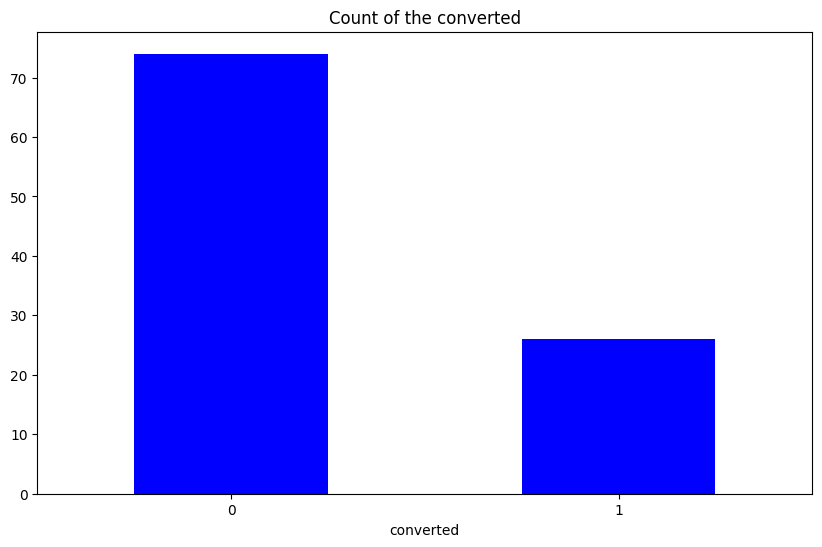

In [133]:
dataClean['converted'].value_counts().plot(kind='bar',figsize=(10,6),color=['blue'])
plt.title("Count of the converted")
plt.xticks(rotation=0);

In [134]:
# Target prediksi
y = df['converted']

# Fitur input (tanpa kolom Perusahaan & converted)
X = df.drop(columns=['converted', 'Perusahaan'])


In [135]:
from sklearn.model_selection import train_test_split

In [136]:
# Membagi fitur dan target menjadi data train dan test (untuk yang oversample saja)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [137]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,roc_auc_score,confusion_matrix,precision_score

def evaluation(Y_test,Y_pred):
    acc = accuracy_score(Y_test,Y_pred)
    rcl = recall_score(Y_test,Y_pred,average = 'weighted')
    f1 = f1_score(Y_test,Y_pred,average = 'weighted')
    ps = precision_score(Y_test,Y_pred,average = 'weighted')

    metric_dict={'accuracy': round(acc,3),
               'recall': round(rcl,3),
               'F1 score': round(f1,3),
               'Precision score': round(ps,3)
              }

    return print(metric_dict)

In [138]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [139]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [140]:
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
print("\nRandom Forest Model:")
accuracy_rf = round(accuracy_score(y_test, y_pred_rf),3)
print("Accuracy:",accuracy_rf)
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Model:
Accuracy: 0.9
Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.60      0.75         5

    accuracy                           0.90        20
   macro avg       0.94      0.80      0.84        20
weighted avg       0.91      0.90      0.89        20



In [145]:
import joblib

# Simpan model
joblib.dump(rf_model, "lead_scoring_model.pkl")

# Simpan dataset
dataClean.to_csv("cleaned_leads_dataset.csv", index=False)
